In [1]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
merged_df = pd.read_csv('data/merged_df.csv')

In [3]:
merged_df['ND_GAIN_class'] = pd.cut(merged_df['ND_GAIN'],
                                    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
                                    labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                                    include_lowest=True)

In [4]:
from itables import show
show(merged_df)

Loading ITables v2.6.2 from the internet... (need help?)


In [5]:
merged_df_2010 = merged_df[merged_df['Year'] == 2010]


In [6]:
# Map ISO3 codes to match world map dataset
# Create a copy to avoid modifying the original dataframe
merged_df_2010_mapped = merged_df_2010.copy()

# Define mappings: ND-GAIN ISO3 -> World Map ISO3
iso3_mappings = {
    'SCG': ['MNE', 'SRB'],  # Serbia and Montenegro -> Montenegro and Serbia
    'ISR': ['PSE'],  # Israel -> Palestine (additional mapping)
    'SDN': ['SSD'],  # Sudan -> South Sudan (additional mapping)
    'CHN': ['TWN']   # China -> Taiwan (additional mapping)
}

# For each mapping, duplicate rows with the new ISO3 codes
additional_rows = []
for source_iso3, target_iso3_list in iso3_mappings.items():
    source_data = merged_df_2010_mapped[merged_df_2010_mapped['ISO3'] == source_iso3]
    if not source_data.empty:
        for target_iso3 in target_iso3_list:
            new_rows = source_data.copy()
            new_rows['ISO3'] = target_iso3
            additional_rows.append(new_rows)

# Concatenate all additional rows to the dataframe
if additional_rows:
    merged_df_2010_mapped = pd.concat([merged_df_2010_mapped] + additional_rows, ignore_index=True)

print(f"Original rows: {len(merged_df_2010)}")
print(f"Rows after mapping: {len(merged_df_2010_mapped)}")

Original rows: 182
Rows after mapping: 187


In [7]:
show(merged_df_2010_mapped)

Loading ITables v2.6.2 from the internet... (need help?)


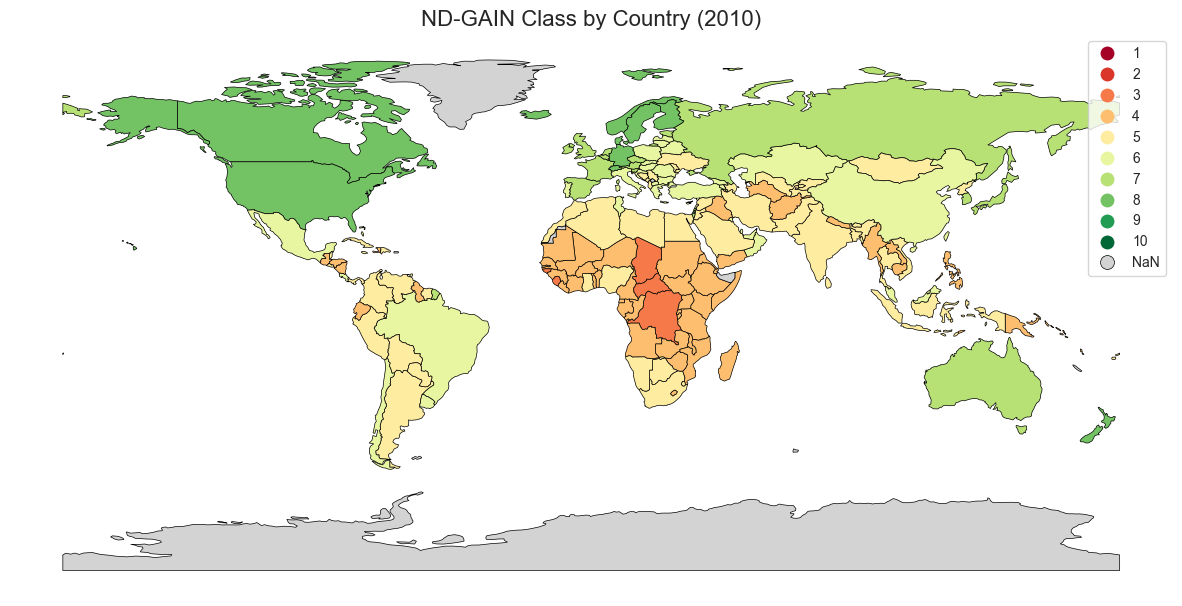

In [8]:
# Load world geometry data directly from Natural Earth
url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(url)

# Use ISO_A3_EH instead of ISO_A3 (ISO_A3_EH has better coverage)
# Merge the world geometry with the MAPPED data based on ISO3 codes
world_merged = world.merge(merged_df_2010_mapped, left_on='ISO_A3_EH', right_on='ISO3', how='left')

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_merged.plot(column='ND_GAIN_class', 
                  ax=ax, 
                  legend=True,
                  cmap='RdYlGn',
                  edgecolor='black',
                  linewidth=0.5,
                  missing_kwds={'color': 'lightgrey'})
ax.set_title('ND-GAIN Class by Country (2010)', fontsize=16)
ax.axis('off')
plt.show()

In [9]:
# Cross-check ISO3 codes between datasets
iso3_in_ndgain = set(merged_df_2010_mapped['ISO3'].dropna().unique())
iso3_in_world = set(world['ISO_A3_EH'].dropna().unique())

# Find codes in ND-GAIN but not in world map
missing_in_world = sorted(iso3_in_ndgain - iso3_in_world)

# Find codes in world map but not in ND-GAIN
missing_in_ndgain = sorted(iso3_in_world - iso3_in_ndgain)

print(f"Total ISO3 codes in ND-GAIN dataset: {len(iso3_in_ndgain)}")
print(f"Total ISO3 codes in World map dataset: {len(iso3_in_world)}")
print(f"\n{'='*60}")
print(f"ISO3 codes in ND-GAIN but NOT in World map ({len(missing_in_world)}):")
print(missing_in_world)
print(f"\n{'='*60}")
print(f"ISO3 codes in World map but NOT in ND-GAIN ({len(missing_in_ndgain)}):")
print(missing_in_ndgain)

Total ISO3 codes in ND-GAIN dataset: 187
Total ISO3 codes in World map dataset: 175

ISO3 codes in ND-GAIN but NOT in World map (20):
['ATG', 'BHR', 'BRB', 'COM', 'CPV', 'DMA', 'GRD', 'KIR', 'LCA', 'MDV', 'MLT', 'MUS', 'PLW', 'SCG', 'SGP', 'STP', 'SYC', 'TON', 'VCT', 'WSM']

ISO3 codes in World map but NOT in ND-GAIN (8):
['-99', 'ATA', 'ATF', 'ESH', 'FLK', 'GRL', 'NCL', 'PRI']


## Coupling GHG, Vulnerability

Vulnerability wird noch umgepolt, damit es aufsteigt

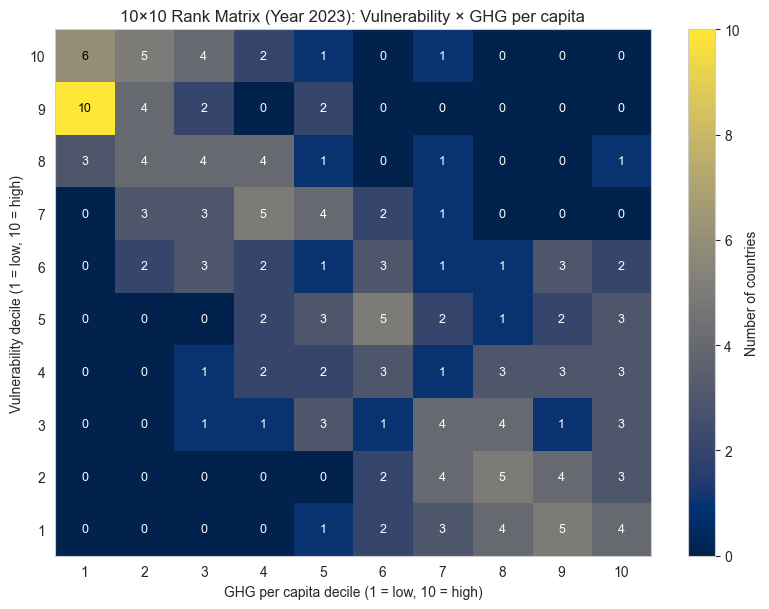

ghg_decile,1,2,3,4,5,6,7,8,9,10
vuln_decile,,,,,,,,,,
1,0,0,0,0,1,2,3,4,5,4
2,0,0,0,0,0,2,4,5,4,3
3,0,0,1,1,3,1,4,4,1,3
4,0,0,1,2,2,3,1,3,3,3
5,0,0,0,2,3,5,2,1,2,3
6,0,2,3,2,1,3,1,1,3,2
7,0,3,3,5,4,2,1,0,0,0
8,3,4,4,4,1,0,1,0,0,1
9,10,4,2,0,2,0,0,0,0,0


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def add_deciles_quantile(dfy: pd.DataFrame, col: str, n_bins: int = 10) -> pd.Series:
    # Wandelt eine kontinuierliche Variable in Rang-basierte Quantile (Deciles) um
    # Wir arbeiten mit Rängen (nicht absoluten Werten), passend zu Spearman/Ranglogik
    # rank(method="first") verhindert Probleme bei vielen gleichen Werten
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


def rank_matrix_10x10(dfy: pd.DataFrame) -> pd.DataFrame:
    # Defensive Kopie, um das Original-DataFrame nicht zu verändern
    dfy = dfy.copy()

    # Emissions-Deciles (1 = niedrige Emissionen, 10 = hohe Emissionen)
    dfy["ghg_decile"] = add_deciles_quantile(dfy, "GHG_per_capita", 10)

    # Vulnerability-Deciles
    # WICHTIG: In deinem Datensatz ist Vulnerability bereits so definiert, dass
    # hohe Werte = hohe Vulnerabilität (z. B. Niger hoch, Schweiz tief).
    # Daher KEINE Inversion hier.
    dfy["vuln_decile"] = add_deciles_quantile(dfy, "Vulnerability", 10)

    # Erzeuge eine 10×10-Rangmatrix (Wert = Anzahl Länder)
    mat = (
        dfy.pivot_table(
            index="vuln_decile",
            columns="ghg_decile",
            values="ISO3",
            aggfunc="nunique",
            fill_value=0
        )
        .reindex(index=range(1, 11), columns=range(1, 11), fill_value=0)
        .astype(int)
    )

    return mat


def plot_rank_matrix(mat: pd.DataFrame, year: int, cmap: str = "cividis") -> None:
    fig, ax = plt.subplots(figsize=(8.2, 6.2))

    # Wichtig gegen "weisses Grid" durch Rendering-Artefakte:
    # origin="lower" => y-Achse: 1 unten, 10 oben (passt zu Label 1=low, 10=high)
    im = ax.imshow(
        mat.values,
        cmap=cmap,
        aspect="auto",
        origin="lower",
        interpolation="none",
        resample=False
    )

    ax.set_title(f"10×10 Rank Matrix (Year {year}): Vulnerability × GHG per capita")
    ax.set_xlabel("GHG per capita decile (1 = low, 10 = high)")
    ax.set_ylabel("Vulnerability decile (1 = low, 10 = high)")

    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    ax.set_xticklabels(range(1, 11))
    ax.set_yticklabels(range(1, 11))

    # Kein Grid
    ax.grid(False)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Number of countries")

    # Textfarbe: weiss auf dunkel (kleine Werte), schwarz auf hell (grosse Werte)
    vmax = mat.values.max() if mat.values.size else 1
    threshold = 0.55 * vmax

    for i in range(10):
        for j in range(10):
            val = int(mat.iat[i, j])
            color = "white" if val <= threshold else "black"
            ax.text(j, i, str(val), ha="center", va="center", color=color, fontsize=9)

    plt.tight_layout()
    plt.show()


def run_rank_matrix(year: int | str = "latest", path: str = "data/merged_df.csv") -> pd.DataFrame:
    df = pd.read_csv(path)

    if year == "latest":
        year = int(df["Year"].max())
    else:
        year = int(year)

    dfy = df[df["Year"] == year].copy()

    mat = rank_matrix_10x10(dfy)
    plot_rank_matrix(mat, year=year, cmap="cividis")

    return mat


# --- Ausführung ---
mat = run_rank_matrix(year="latest", path="data/merged_df.csv")
mat


### Kontrolle Polaritäten Vulnerability über Extremwerte

In [11]:
# Schau dir die Extremwerte an
# Datensatz explizit laden
df = pd.read_csv("data/merged_df.csv")

# Letztes Jahr bestimmen
latest_year = int(df["Year"].max())

# Auf letztes Jahr filtern
dfy = df[df["Year"] == latest_year].copy()

# Extremwerte anschauen
print("HÖCHSTE Vulnerability-Werte:")
display(
    dfy.sort_values("Vulnerability", ascending=False)
       [["Country", "ISO3", "Vulnerability"]]
       .head(15)
)

print("\nNIEDRIGSTE Vulnerability-Werte:")
display(
    dfy.sort_values("Vulnerability", ascending=True)
       [["Country", "ISO3", "Vulnerability"]]
       .head(15)
)



HÖCHSTE Vulnerability-Werte:


,Country,ISO3,Vulnerability
4581,Chad,TCD,0.639627
3450,Niger,NER,0.632981
4233,Solomon Islands,SLB,0.629253
1884,Guinea-Bissau,GNB,0.612813
4146,Sudan and South Sudan,SDN,0.611921
4320,Somalia,SOM,0.610504
4755,Tonga,TON,0.606593
4262,Sierra Leone,SLE,0.597257
1507,Eritrea,ERI,0.591530
28,Afghanistan,AFG,0.587516



NIEDRIGSTE Vulnerability-Werte:


,Country,ISO3,Vulnerability
869,Switzerland,CHE,0.251258
3566,Norway,NOR,0.255615
1246,Czechia,CZE,0.263809
1623,Finland,FIN,0.280200
840,Canada,CAN,0.281584
1739,United Kingdom,GBR,0.288056
2348,"Israel and Palestine, State of",ISR,0.289366
260,Austria,AUT,0.295317
1275,Germany,DEU,0.301489
1681,France,FRA,0.304166


Loading ITables v2.6.2 from the internet... (need help?)


C:\Users\alexi\Alexis\Projects\FHNW\ciCH\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10231 (\N{LONG LEFT RIGHT ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


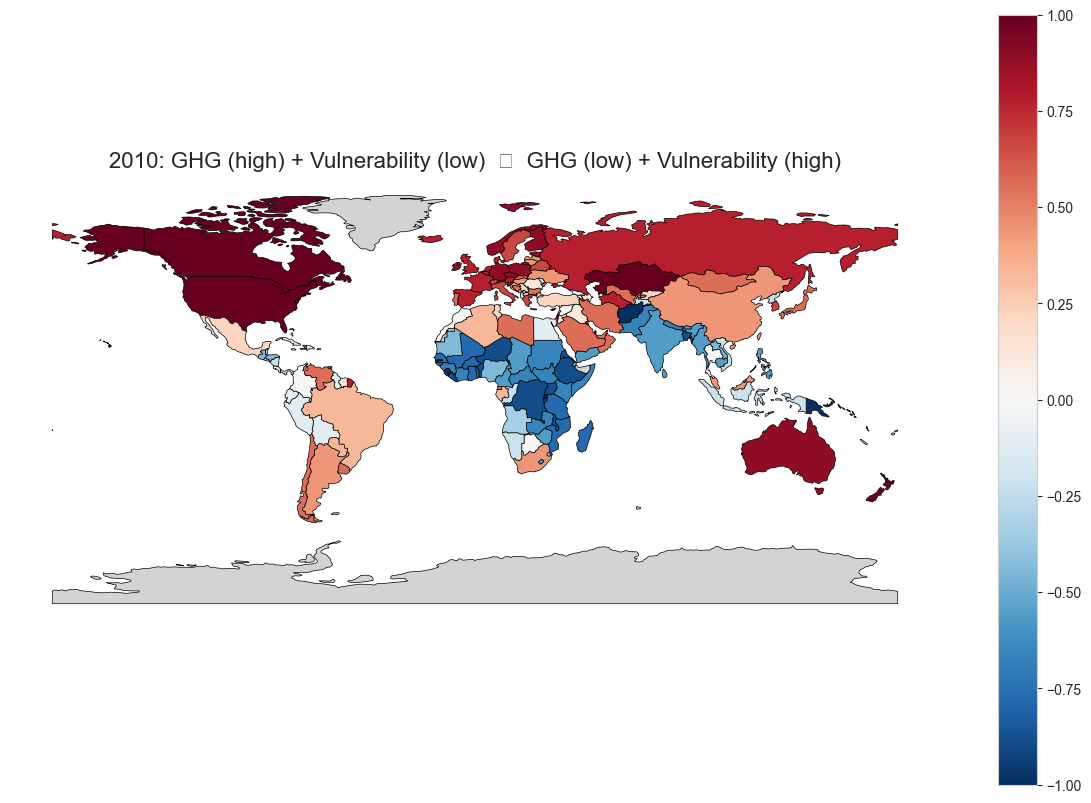

In [12]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from itables import show


def add_deciles_quantile(dfy: pd.DataFrame, col: str, n_bins: int = 10) -> pd.Series:
    # Rang-basierte Deciles, robust bei vielen gleichen Werten
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


# --- 1) Deciles + Kombi-Score auf deinem 2010-Frame erzeugen ---
# Annahme: merged_df_2010_mapped hat Spalten: ISO3, GHG_per_capita, Vulnerability
merged_df_2010_mapped = merged_df_2010_mapped.copy()

# GHG: 1 = low, 10 = high
merged_df_2010_mapped["ghg_decile"] = add_deciles_quantile(merged_df_2010_mapped, "GHG_per_capita", 10)

# Vulnerability: 1 = low, 10 = high (bei dir ist das bereits so orientiert!)
merged_df_2010_mapped["vuln_decile"] = add_deciles_quantile(merged_df_2010_mapped, "Vulnerability", 10)

# Kombi-Index:
# + hoch, wenn GHG hoch UND Vulnerability tief
# - tief, wenn GHG tief UND Vulnerability hoch
merged_df_2010_mapped["ghg_minus_vuln"] = merged_df_2010_mapped["ghg_decile"] - merged_df_2010_mapped["vuln_decile"]
# Wertebereich: -9 ... +9

# Optional: normalisieren auf [-1, +1] (praktisch für Legende/vergleich)
merged_df_2010_mapped["ghg_minus_vuln_norm"] = merged_df_2010_mapped["ghg_minus_vuln"] / 9.0

show(merged_df_2010_mapped)


# --- 2) Welt-Geometrie laden und mergen ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world_merged = world.merge(
    merged_df_2010_mapped,
    left_on="ISO_A3_EH",
    right_on="ISO3",
    how="left"
)


# --- 3) Plot: Diverging Colormap (zwei Extreme) ---
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Diverging cmap: negativ = forced-rider Extrem, positiv = free-rider Extrem
# (Du kannst auch "coolwarm" nehmen; das ist ebenfalls diverging.)
world_merged.plot(
    column="ghg_minus_vuln_norm",      # <- der neue Score
    ax=ax,
    legend=True,
    cmap="RdBu_r",                     # blau = negativ, rot = positiv (umgedreht im Zweifel)
    edgecolor="black",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey"},
    vmin=-1, vmax=1                    # symmetrisch, damit 0 = neutral wirklich Mitte ist
)

ax.set_title(
    "2010: GHG (high) + Vulnerability (low)  ⟷  GHG (low) + Vulnerability (high)",
    fontsize=16
)
ax.axis("off")
plt.show()


Loading ITables v2.6.2 from the internet... (need help?)


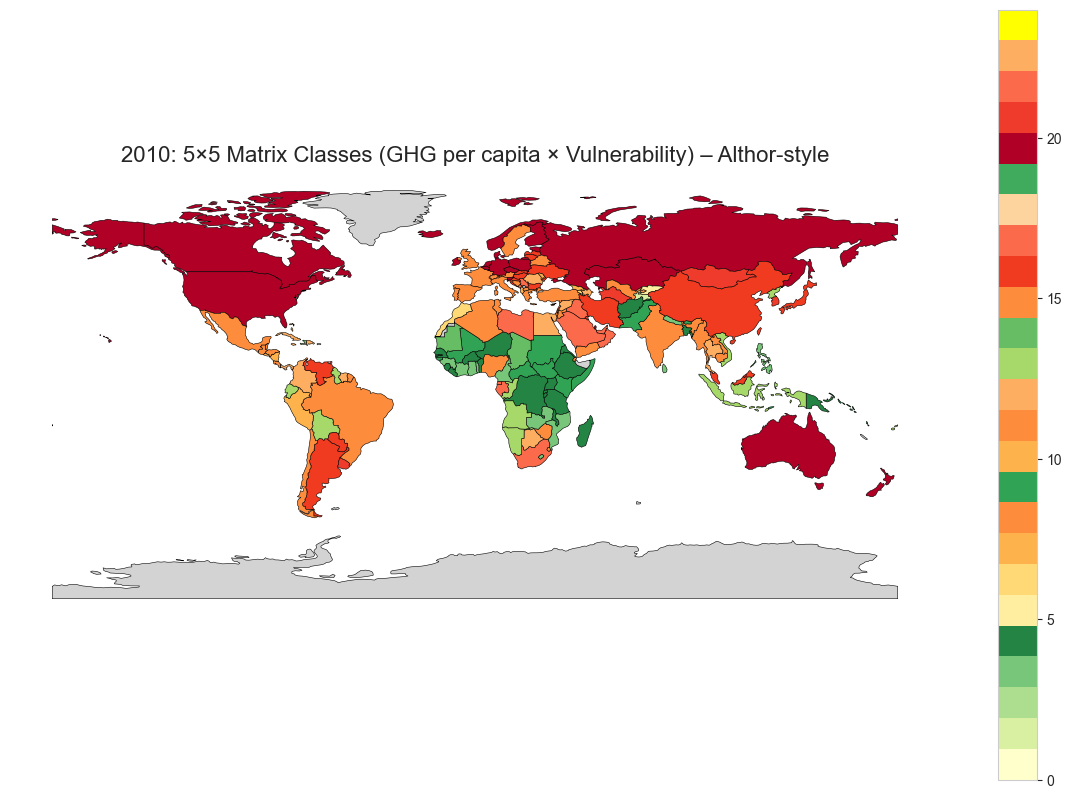

In [13]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from itables import show


def add_quantile_bins(dfy: pd.DataFrame, col: str, n_bins: int = 5) -> pd.Series:
    # Rang-basierte Quantile (robust bei ties)
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


# --- 1) Quintile auf deinem 2010-Frame erzeugen ---
# Achsenlogik wie bei Althor:
#   x: Vulnerability (1 = low, 5 = high)
#   y: Emissions level (1 = low, 5 = high)
df5 = merged_df_2010_mapped.copy()

df5["ghg_q"] = add_quantile_bins(df5, "GHG_per_capita", 5)     # 1..5 (low..high)
df5["vuln_q"] = add_quantile_bins(df5, "Vulnerability", 5)     # 1..5 (low..high)

# Cell-ID: 25 Klassen
# Wir wollen eine eindeutige Klasse pro 5×5-Zelle.
# Reihenfolge (optional): y = ghg_q von low->high, x = vuln_q von low->high
# cell_id in [0..24] (praktisch für colormap)
df5["cell_id"] = (df5["ghg_q"] - 1) * 5 + (df5["vuln_q"] - 1)

# Optional: Für Tabelle sichtbar machen
show(df5[["Country","ISO3","Year","GHG_per_capita","Vulnerability","ghg_q","vuln_q","cell_id"]].head(30))


# --- 2) Althor-ähnliche 5×5 Farbcodes definieren ---
# Idee: Oben links (high GHG, low vuln) = "free rider" = rot/dunkelrot
#       Unten rechts (low GHG, high vuln) = "forced rider" = grün/dunkelgrün
#
# Achtung: Matplotlib colormap läuft von index 0..24.
# Unser cell_id ist so aufgebaut:
#   ghg_q steigt nach unten im Array (row-major), vuln_q nach rechts.
# Farbmatrix bauen wir aber bewusst als 5×5 "logical grid":
# rows = ghg_q low->high, cols = vuln_q low->high
#
# Du kannst die Farben später 1:1 feinjustieren.

# 5x5 Farben: rot -> gelb -> grün (Althor-like)
# row 0 = low emissions, row 4 = high emissions
# col 0 = low vulnerability, col 4 = high vulnerability
color_grid = np.array([
    ["#ffffcc", "#d9f0a3", "#addd8e", "#78c679", "#238443"],  # low ghg
    ["#ffeda0", "#fed976", "#feb24c", "#fd8d3c", "#31a354"],
    ["#feb24c", "#fd8d3c", "#fdae61", "#a6d96a", "#66bd63"],
    ["#fd8d3c", "#f03b20", "#fb6a4a", "#fdd49e", "#41ab5d"],
    ["#b10026", "#ef3b2c", "#fb6a4a", "#fdae61", "#ffff00"],  # high ghg (links rot)
], dtype=object)

# Hinweis:
# In Althor ist "free rider" oben links (high ghg, low vuln).
# Unser grid hat high ghg in der letzten Zeile (row 4), low vuln in col 0.
# Damit free rider "row 4, col 0" rot wird, muss die letzte Zeile links rot sein.
# forced rider (low ghg, high vuln) = row 0, col 4 = grün -> passt.

# In ListedColormap muss es eine flache Liste sein, in der Reihenfolge cell_id 0..24:
# cell_id = (ghg_q-1)*5 + (vuln_q-1) => row-major
cmap_althor = ListedColormap(color_grid.reshape(-1).tolist())


# --- 3) Welt-Geometrie laden und mergen ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world_merged = world.merge(
    df5,
    left_on="ISO_A3_EH",
    right_on="ISO3",
    how="left"
)


# --- 4) Plot: diskrete 25 Klassen (5×5) statt Streifen ---
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

world_merged.plot(
    column="cell_id",
    ax=ax,
    legend=True,
    cmap=cmap_althor,
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "lightgrey"},
    vmin=0, vmax=24
)

ax.set_title("2010: 5×5 Matrix Classes (GHG per capita × Vulnerability) – Althor-style", fontsize=16)
ax.axis("off")
plt.show()


C:\Users\alexi\AppData\Local\Temp\ipykernel_47472\1801699419.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


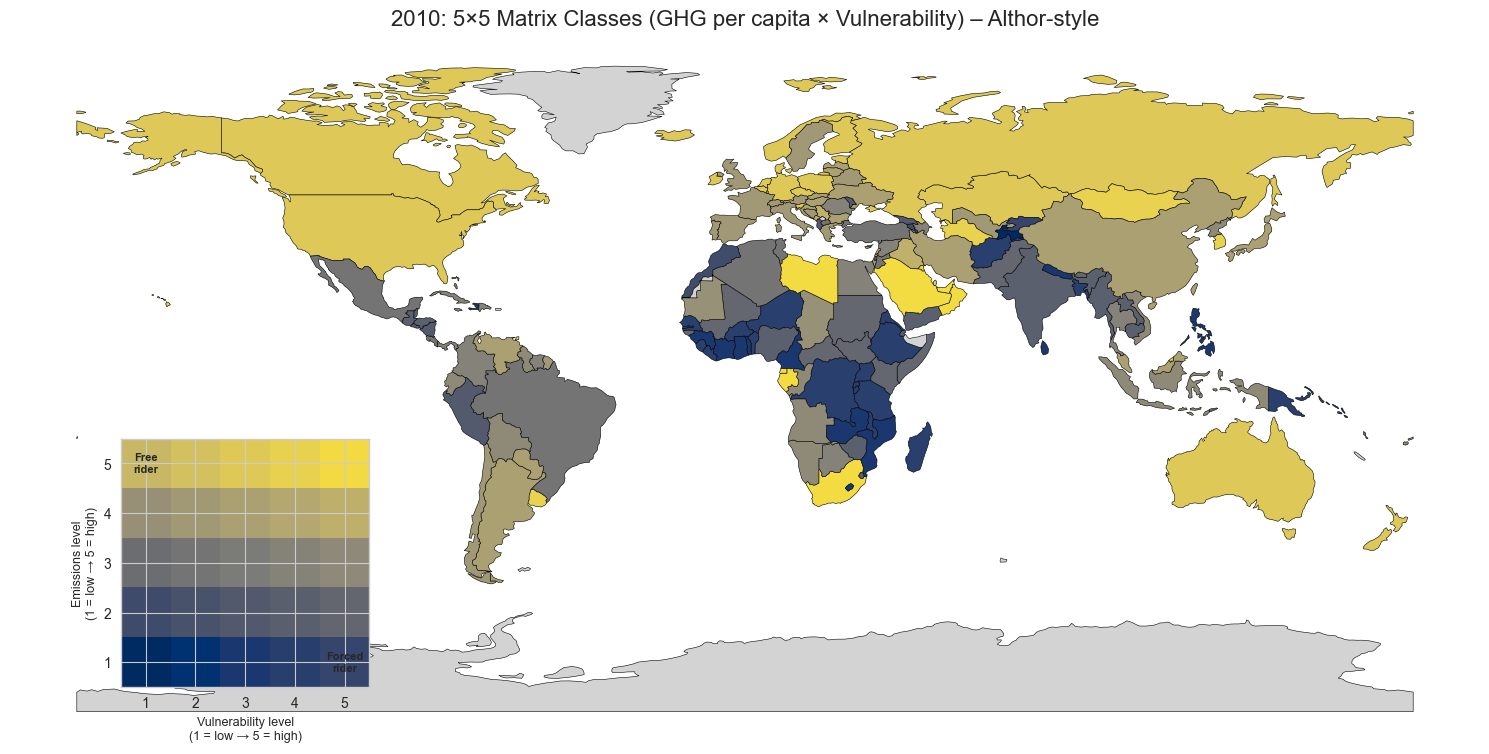

In [14]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def add_quantile_bins(dfy: pd.DataFrame, col: str, n_bins: int = 5) -> pd.Series:
    # Rang-basierte Quantile (robust bei ties)
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


def make_5x5_cmap(base_cmap_name: str = "cividis") -> tuple[ListedColormap, np.ndarray]:
    """
    Erzeugt eine diskrete 25-Farben-Map aus einem farbenblind-tauglichen Continuous-Cmap.
    Gleichzeitig wird eine 5×5-Farbmatrix zurückgegeben (für die inset-Legende).
    """
    base = plt.get_cmap(base_cmap_name)

    # 25 diskrete Farben gleichmässig aus der Continuous-Cmap sampeln
    colors = [base(x) for x in np.linspace(0.05, 0.95, 25)]
    cmap25 = ListedColormap(colors)

    # In 5×5 Rasterform bringen (row-major)
    color_grid = np.arange(25).reshape(5, 5)  # Werte 0..24, nur fuer Legendenbild
    return cmap25, color_grid


# --- 1) Quintile + 25 Klassen (wie Althor: 5×5) ---
df5 = merged_df_2010_mapped.copy()

# Achsenlogik wie bei Althor:
# x: Vulnerability (1 = low, 5 = high)
# y: Emissions level (1 = low, 5 = high)
df5["ghg_q"] = add_quantile_bins(df5, "GHG_per_capita", 5)   # 1..5
df5["vuln_q"] = add_quantile_bins(df5, "Vulnerability", 5)   # 1..5

# cell_id: 0..24 (row-major)
# row = ghg_q-1 (low->high), col = vuln_q-1 (low->high)
df5["cell_id"] = (df5["ghg_q"] - 1) * 5 + (df5["vuln_q"] - 1)


# --- 2) Welt-Geometrie mergen ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world_merged = world.merge(
    df5,
    left_on="ISO_A3_EH",
    right_on="ISO3",
    how="left"
)


# --- 3) Colormap: farbenblind-tauglich (Blau–Gelb) ---
# Empfehlung: "cividis" (sehr gut für Farbblindheit), alternativ: "viridis"
cmap25, legend_grid = make_5x5_cmap(base_cmap_name="cividis")


# --- 4) Plot: Karte OHNE Streifen-Colorbar + Inset 5×5 Farbmatrix ---
fig, ax = plt.subplots(1, 1, figsize=(15, 9))

world_merged.plot(
    column="cell_id",
    ax=ax,
    cmap=cmap25,
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("2010: 5×5 Matrix Classes (GHG per capita × Vulnerability) – Althor-style", fontsize=16)
ax.axis("off")


# --- 5) Inset: 5×5 Farbmatrix-Legende (wie im Paper) ---
# Inset-Achse platzieren (links unten wie Althor; bei Bedarf bbox_to_anchor anpassen)
ax_leg = inset_axes(
    ax,
    width="22%", height="35%",
    loc="lower left",
    bbox_to_anchor=(0.05, 0.08, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

# 5×5 Matrix anzeigen (origin="lower" => unten = low emissions, oben = high emissions)
im_leg = ax_leg.imshow(
    legend_grid,
    cmap=cmap25,
    origin="lower",
    interpolation="none"
)

# Achsenticks/Labels wie Althor
ax_leg.set_xticks(range(5))
ax_leg.set_yticks(range(5))
ax_leg.set_xticklabels([1, 2, 3, 4, 5])
ax_leg.set_yticklabels([1, 2, 3, 4, 5])

ax_leg.set_xlabel("Vulnerability level\n(1 = low → 5 = high)", fontsize=9)
ax_leg.set_ylabel("Emissions level\n(1 = low → 5 = high)", fontsize=9)

# Optional: Ecken labels (Free/Forced) wie im Paper
# Althor: Free rider = high emissions + low vulnerability => (y=5, x=1) => top-left
# Forced rider = low emissions + high vulnerability => (y=1, x=5) => bottom-right
ax_leg.text(0, 4, "Free\nrider", ha="center", va="center", fontsize=8, fontweight="bold")
ax_leg.text(4, 0, "Forced\nrider", ha="center", va="center", fontsize=8, fontweight="bold")

# Rahmen klar machen
for spine in ax_leg.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()
